## 1. Import Library and Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_excel("WHR26_Data_Figure_2.1.xlsx")

df.head()

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


## 2. Data Preparation & Exploration

In [4]:
df.shape

(2116, 13)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

In [6]:
missing = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing)

,Jumlah Missing,Persentase (%)
Year,0,0.00
Rank,0,0.00
Country name,0,0.00
Life evaluation (3-year average),0,0.00
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Explained by: Log GDP per capita,1097,51.84
Explained by: Social support,1097,51.84
Explained by: Healthy life expectancy,1100,51.98
Explained by: Freedom to make life choices,1099,51.94


## Q1: Bagaimana menurut Anda tingkat kebahagiaan di Indonesia berdasarkan hasil survey dari WHR pada 5 tahun terakhir?

In [7]:
df_id = df[
    (df['Country name'] == 'Indonesia') &
    (df['Year']).between(2021,2026)
].copy().sort_values('Year')

df_id

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
660,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300
520,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
373,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
229,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
86,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020


In [8]:
df_id["Life evaluation (3-year average)"].describe()

count    5.00000
mean     5.46380
std      0.18893
min      5.24000
25%      5.27700
50%      5.56800
75%      5.61700
max      5.61700
Name: Life evaluation (3-year average), dtype: float64

In [9]:
mean = df_id["Life evaluation (3-year average)"].mean()
median = df_id["Life evaluation (3-year average)"].median()

print("Mean:", mean)
print("Median:", median)

Mean: 5.463800000000001
Median: 5.568


In [10]:
idx_max = df_id["Life evaluation (3-year average)"].idxmax()
idx_min = df_id["Life evaluation (3-year average)"].idxmin()

print(df_id.loc[idx_max, ["Year", "Life evaluation (3-year average)"]])
print(df_id.loc[idx_min, ["Year", "Life evaluation (3-year average)"]])

Year                                2024.000
Life evaluation (3-year average)       5.617
Name: 229, dtype: float64
Year                                2021.00
Life evaluation (3-year average)       5.24
Name: 660, dtype: float64


In [13]:
first = df_id.iloc[0]["Life evaluation (3-year average)"]
last = df_id.iloc[-1]["Life evaluation (3-year average)"]

change = last - first
change_pct = (change / first) * 100

print("Perubahan skor:", change.round(2))
print("Persentase perubahan:", change_pct.round(2),'%')

Perubahan skor: 0.38
Persentase perubahan: 7.19 %


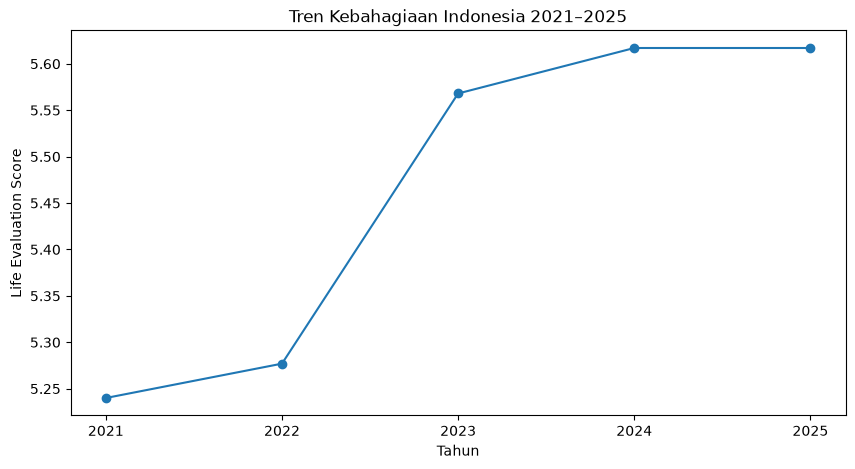

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    df_id["Year"],
    df_id["Life evaluation (3-year average)"],
    marker="o"
)

plt.title("Tren Kebahagiaan Indonesia 2021–2025")
plt.xlabel("Tahun")
plt.ylabel("Life Evaluation Score")
plt.xticks(df_id["Year"])

plt.show()

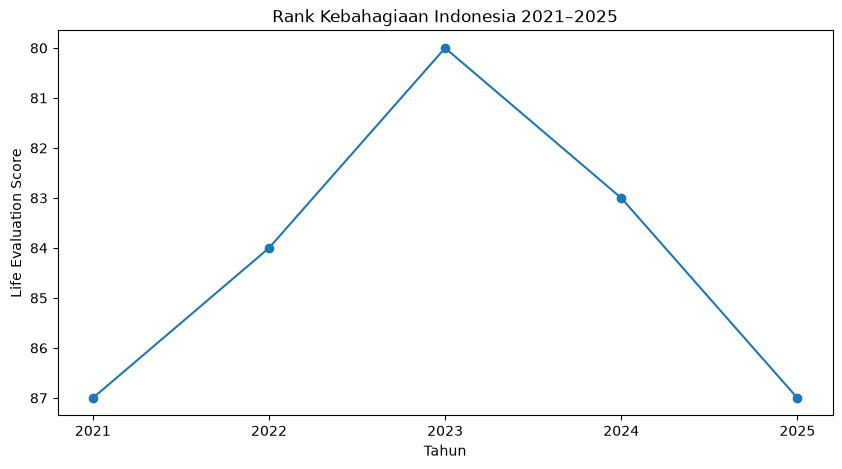

In [90]:
plt.figure(figsize=(10,5))

plt.plot(
    df_id["Year"],
    df_id["Rank"],
    marker="o"
)

plt.title("Rank Kebahagiaan Indonesia 2021–2025")
plt.xlabel("Tahun")
plt.ylabel("Life Evaluation Score")
plt.xticks(df_id["Year"])
plt.gca().invert_yaxis()

plt.show()

## Q2: Menurut Anda apa saja faktor-faktor yang mempengaruhi skor kebahagiaan di Indonesia dalam 5 tahun terakhir?

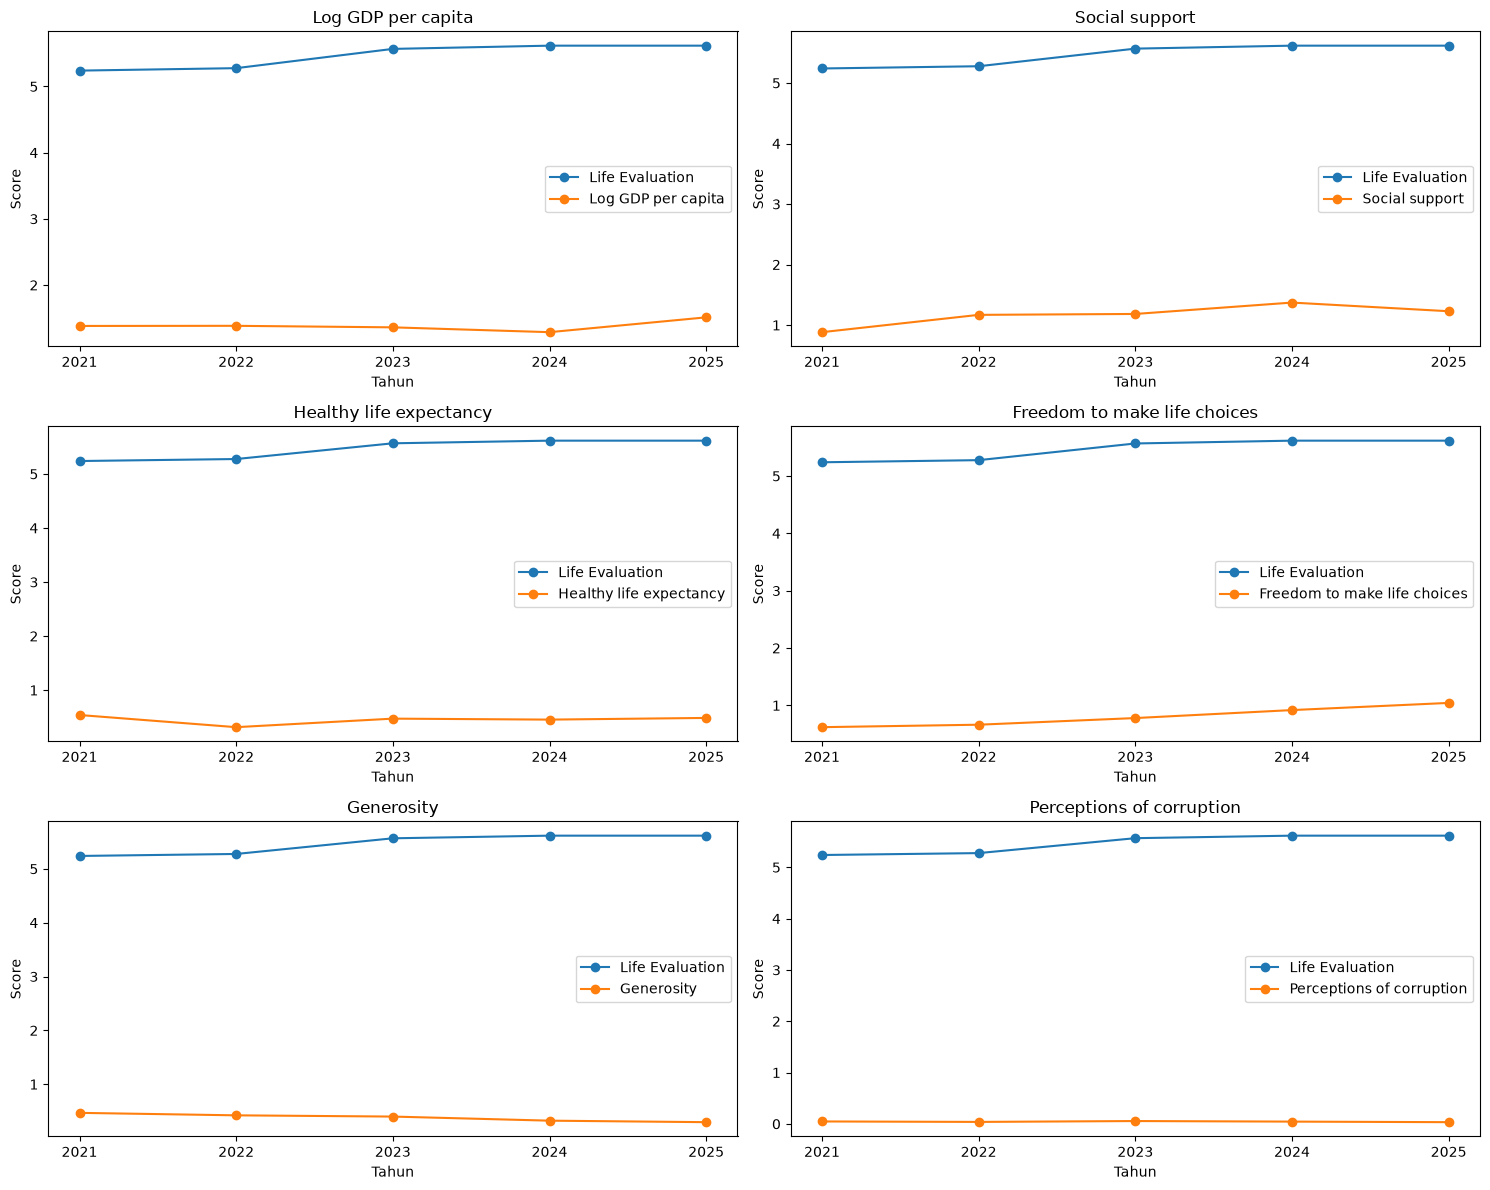

In [24]:
factors = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for ax, factor in zip(axes.flatten(), factors):

    ax.plot(
        df_id["Year"],
        df_id["Life evaluation (3-year average)"],
        marker="o",
        label="Life Evaluation"
    )

    ax.plot(
        df_id["Year"],
        df_id[factor],
        marker="o",
        label=factor.replace("Explained by: ", "")
    )

    ax.set_title(factor.replace("Explained by: ", ""))
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Score")
    ax.set_xticks(df_id["Year"])
    ax.legend()

plt.tight_layout()
plt.show()

5.463800000000001
0.18893041046904
660   -1.184563
520   -0.988724
373    0.551526
229    0.810881
86     0.810881
Name: Life evaluation (3-year average), dtype: float64
1.3854
0.08081336523125367
660   -0.042072
520   -0.017324
373   -0.301930
229   -1.205246
86     1.566573
Name: Explained by: Log GDP per capita, dtype: float64
1.1674
0.17805701334123294
660   -1.597241
520    0.008986
373    0.093229
229    1.149070
86     0.345957
Name: Explained by: Social support, dtype: float64
0.4528
0.08381944881708542
660    1.028401
520   -1.655940
373    0.229064
229    0.014316
86     0.384159
Name: Explained by: Healthy life expectancy, dtype: float64
0.8046
0.17640663252837177
660   -1.046446
520   -0.802691
373   -0.145119
229    0.642833
86     1.351423
Name: Explained by: Freedom to make life choices, dtype: float64
0.3814
0.07129726502468381
660    1.214633
520    0.569447
373    0.246854
229   -0.819106
86    -1.211828
Name: Explained by: Generosity, dtype: float64
0.0434
0.00844393

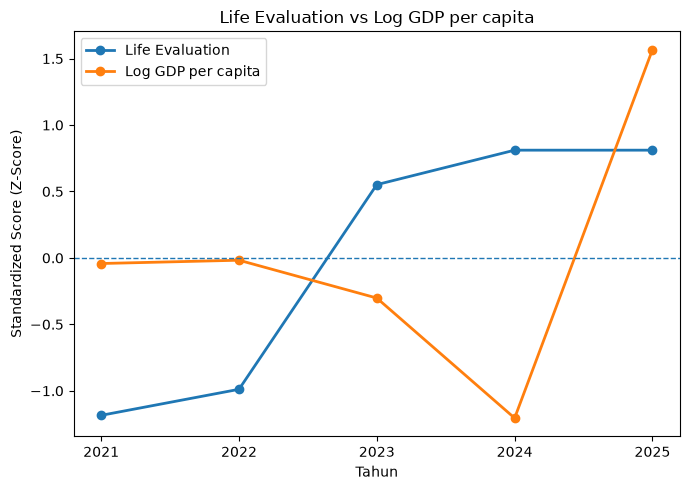

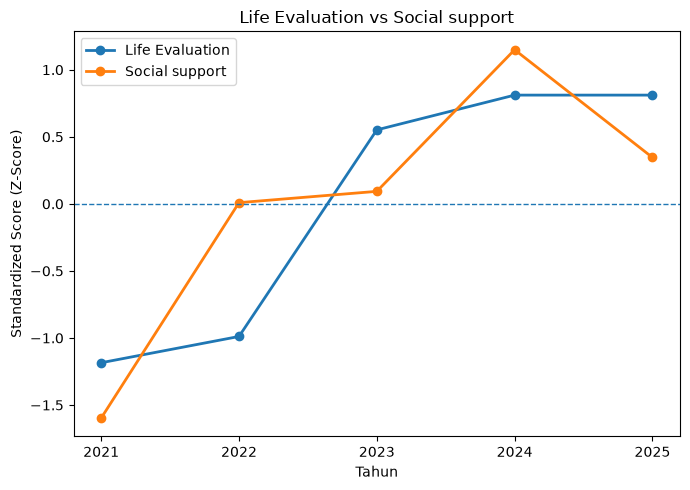

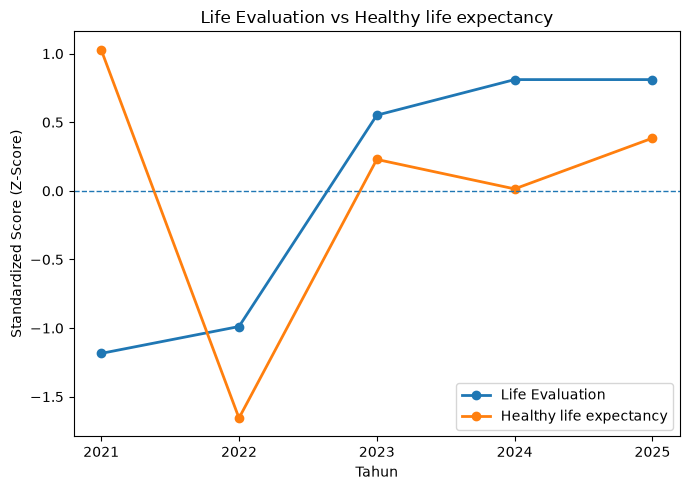

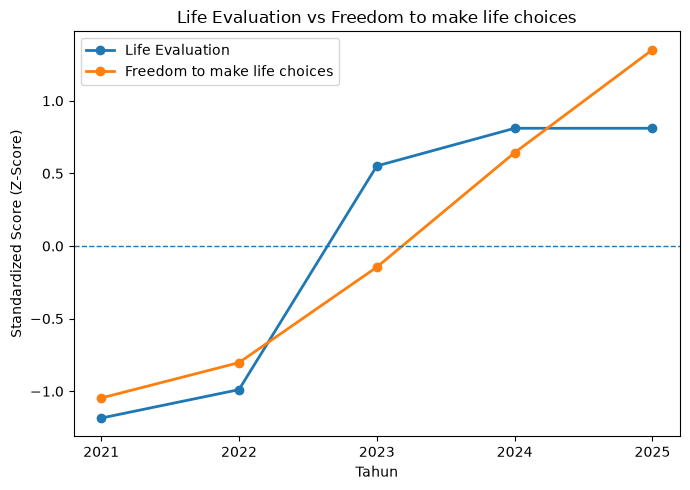

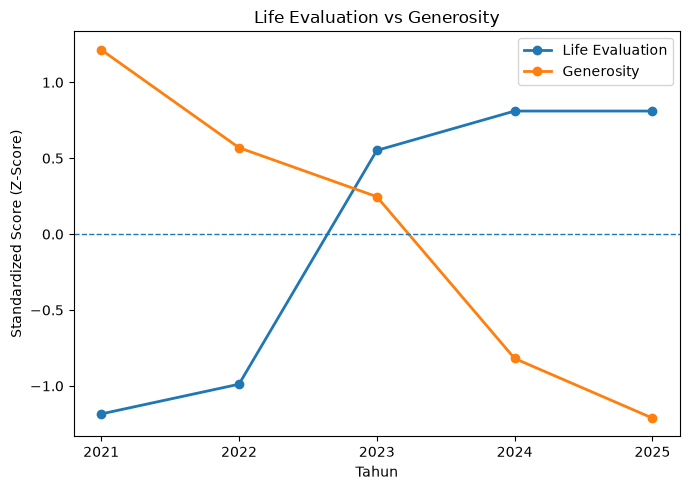

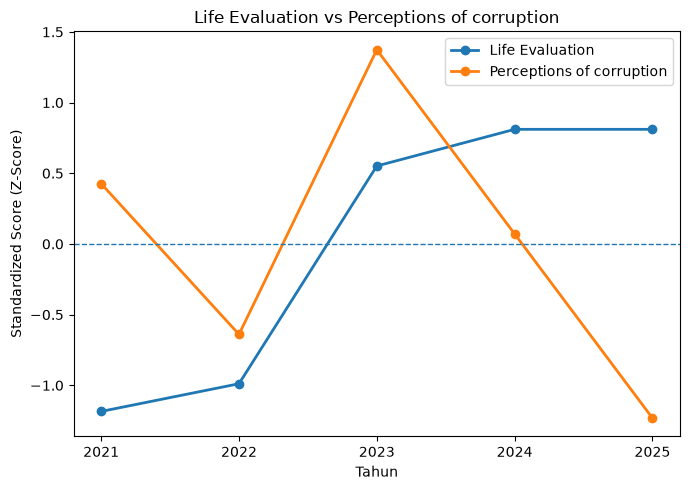

In [92]:
factors = [
    "Explained by: Log GDP per capita",
    "Explained by: Social support",
    "Explained by: Healthy life expectancy",
    "Explained by: Freedom to make life choices",
    "Explained by: Generosity",
    "Explained by: Perceptions of corruption"
]

# Buat salinan data
df_scaled = df_id[["Year", "Life evaluation (3-year average)"]+ factors ].copy()

# Standardisasi dengan Z-score
columns = ["Life evaluation (3-year average)"] +factors

for column in columns:
    # print(df_scaled[column])
    print(df_scaled[column].mean())
    print(df_scaled[column].std())
    df_scaled[column] = (
        df_scaled[column] - df_scaled[column].mean()
    ) / df_scaled[column].std()
    print(df_scaled[column])

df_scaled


for factor in factors:

    plt.figure(figsize=(7, 5))

    # Life Evaluation
    plt.plot(
        df_scaled["Year"],
        df_scaled["Life evaluation (3-year average)"],
        marker="o",
        linewidth=2,
        label="Life Evaluation"
    )

    # Faktor
    plt.plot(
        df_scaled["Year"],
        df_scaled[factor],
        marker="o",
        linewidth=2,
        label=factor.replace("Explained by: ", "")
    )

    # Garis rata-rata
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Life Evaluation vs {factor.replace('Explained by: ', '')}"
    )
    plt.xlabel("Tahun")
    plt.ylabel("Standardized Score (Z-Score)")
    plt.xticks(df_scaled["Year"])
    plt.legend()

    plt.tight_layout()
    plt.show()

## Q3: Bagaimana menurut Anda skor kebahagiaan di Indonesia jika dibandingkan dengan negara lain di Asia Tenggara dalam 5 terakhir?

In [87]:
asean = [
    "Indonesia",
    "Thailand",
    "Philippines",
    "Viet Nam",
    "Malaysia",
    "Singapore",
    "Myanmar",
    "Cambodia",
    "Brunei Darussalam"
]

df_asean = df[
    df["Country name"].isin(asean) &
    df["Year"].between(2021, 2025)
].copy()
df_asean

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
35,2025,36,Singapore,6.585,6.497,6.674,2.167,1.471,1.059,0.980,0.145,0.512,0.252
44,2025,45,Viet Nam,6.428,6.353,6.504,1.510,1.375,0.698,1.147,0.039,0.207,1.453
51,2025,52,Thailand,6.296,6.187,6.405,1.632,1.424,0.694,1.087,0.195,0.029,1.234
55,2025,56,Philippines,6.206,6.097,6.315,1.413,1.285,0.286,1.085,0.088,0.095,1.953
70,2025,71,Malaysia,6.005,5.901,6.110,1.766,1.170,0.413,1.109,0.161,0.112,1.275
86,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020
120,2025,121,Cambodia,4.462,4.354,4.569,1.295,1.075,0.531,1.123,0.148,0.088,0.201
128,2025,129,Myanmar,4.287,4.144,4.430,1.211,0.977,0.488,0.722,0.292,0.160,0.436
180,2024,34,Singapore,6.565,6.481,6.650,2.022,1.565,0.935,0.856,0.164,0.522,0.501
192,2024,46,Viet Nam,6.352,6.280,6.424,1.278,1.533,0.631,1.012,0.039,0.174,1.684


Country name
Singapore      6.5480
Thailand       6.0456
Viet Nam       6.0142
Philippines    5.9576
Malaysia       5.9316
Indonesia      5.4638
Cambodia       4.4354
Myanmar        4.3456
Name: Life evaluation (3-year average), dtype: float64

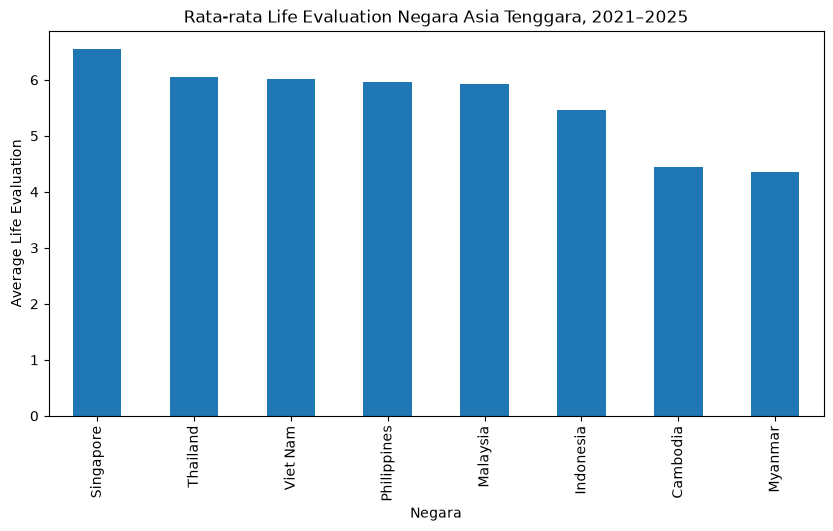

In [88]:
asean_avg = (
    df_asean
    .groupby("Country name")["Life evaluation (3-year average)"]
    .mean()
    .sort_values(ascending=False)
)

display(asean_avg)

asean_avg.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Rata-rata Life Evaluation Negara Asia Tenggara, 2021–2025")
plt.xlabel("Negara")
plt.ylabel("Average Life Evaluation")

plt.show()

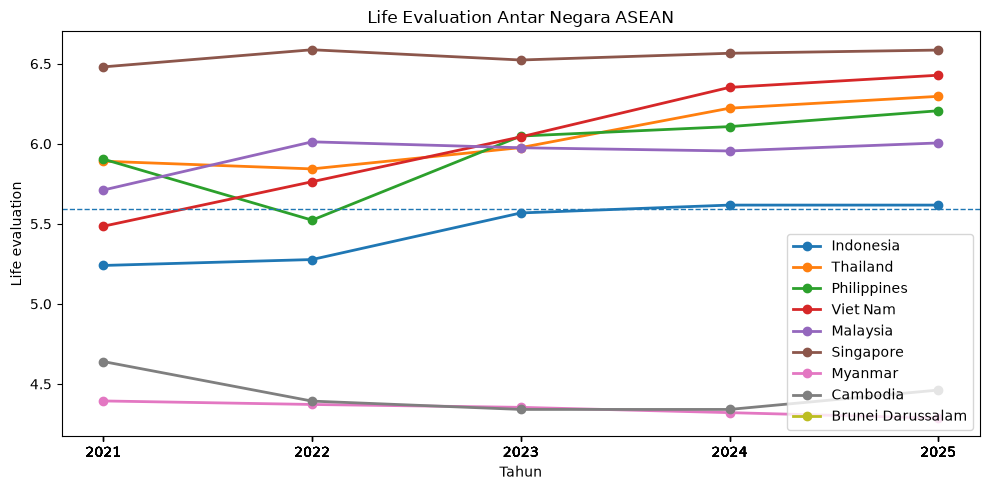

In [89]:
plt.figure(figsize=(10, 5))


for country in asean:
    # Life Evaluation
    plt.plot(
        df_asean.loc[df['Country name']== country,"Year"],
        df_asean.loc[df['Country name']== country,"Life evaluation (3-year average)"],
        marker="o",
        linewidth=2,
        label=country
    )

# Garis rata-rata
plt.axhline(
    df_asean['Life evaluation (3-year average)'].mean(),
    linestyle="--",
    linewidth=1
)

plt.title(
    f"Life Evaluation Antar Negara ASEAN"
)
plt.xlabel("Tahun")
plt.ylabel("Life evaluation")
plt.xticks(df_asean["Year"])
plt.legend()

plt.tight_layout()
plt.show()